# CSP-8 : Temporels - Raisonnement sur le Temps

**Navigation** : [<< CSP-7-Soft](CSP-7-Soft.ipynb) | [Index](../README.md) | [CSP-9-Distributed >>](CSP-9-Distributed.ipynb)

## Problemes de Satisfaction de Contraintes Temporels

Ce notebook explore les techniques de raisonnement **temporel** en programmation par contraintes. Les CSP temporels permettent de modeliser des contraintes sur des evenements, durees et ordonnancement temporel.

### Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Comprendre** Allen's Interval Algebra et ses 13 relations (Bloom : comprendre)
2. **Implementer** le Simple Temporal Problem (STP) (Bloom : appliquer)
3. **Resoudre** des contraintes temporelles avec Floyd-Warshall (Bloom : appliquer)
4. **Etendre** vers TCSP pour problemes plus complexes (Bloom : analyser)
5. **Appliquer** a la planification avec fenetres de temps (Bloom : evaluer)

### Prerequis
- Search-6 : formalisme CSP
- Search-7 : propagation de contraintes, arc consistency
- Bases de theorie des graphes (plus courts chemins)

### Duree estimee : 60 minutes

In [1]:
# Installation des dependances
import subprocess
import sys

def install_if_missing(package):
    try:
        __import__(package.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing('networkx')
install_if_missing('matplotlib')
install_if_missing('numpy')

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass
from enum import Enum
from itertools import product

print("Dependances pretes.")

Dependances pretes.


---

## 1. Introduction : Raisonnement Temporel (~10 min)

Le raisonnement temporel est fondamental en IA pour :
- **Planification** : ordonner des actions dans le temps
- **Comprehension du langage** : "avant", "pendant", "apres"
- **Ordonnancement** : fenetres de temps, deadlines

### Deux paradigmes

| Paradigme | Representation | Complexite | Exemples |
|-----------|----------------|------------|----------|
| **Qualitatif** | Relations entre intervalles | NP-hard | Allen's Algebra |
| **Quantitatif** | Contraintes numeriques | Polynomial (STP) | STP, TCSP |

### Point vs Intervalle

- **Point algebra** : relations entre instants (<, =, >)
- **Interval algebra** : relations entre durees (Allen's 13 relations)

---

## 2. Allen's Interval Algebra (~15 min)

**Allen's Interval Algebra** (1983) definit **13 relations de base** entre deux intervalles temporels.

### Les 13 relations atomiques

```
A before B      : AAAAAAA                 BBBBBBB
A meets B       : AAAAAAA|BBBBBBB
A overlaps B    : AAAAAAA
                      BBBBBBB
A starts B      : AAAAAAA
                 BBBBBBBBBBBBB
A during B      :    AAAAAAA
                 BBBBBBBBBBBBB
A finishes B    :       AAAAAAA
                 BBBBBBBBBBBBB
A equals B      : AAAAAAA
                 BBBBBBB
```

### Operations algebriques

- **Converse** : $R^{-1}$ (ex: before$^{-1}$ = after)
- **Composition** : $R_1 \circ R_2$ (table de transitivite)
- **Union** : $R_1 \cup R_2$ (disjonction)

In [2]:
class AllenRelation(Enum):
    """13 relations atomiques d'Allen."""
    BEFORE = 'b'        # A avant B (pas de contact)
    MEETS = 'm'         # A touche B (A finit ou B commence)
    OVERLAPS = 'o'      # A chevauche B
    STARTS = 's'        # A commence en meme temps que B (A plus court)
    DURING = 'd'        # A est contenu dans B
    FINISHES = 'f'      # A finit en meme temps que B (A plus court)
    EQUALS = 'e'        # A = B
    FINISHED_BY = 'F'   # converse of FINISHES
    CONTAINS = 'D'      # converse of DURING
    STARTED_BY = 'S'    # converse of STARTS
    OVERLAPPED_BY = 'O' # converse of OVERLAPS
    MET_BY = 'M'        # converse of MEETS
    AFTER = 'B'         # converse of BEFORE

# Table de conversion converse
CONVERSE = {
    AllenRelation.BEFORE: AllenRelation.AFTER,
    AllenRelation.MEETS: AllenRelation.MET_BY,
    AllenRelation.OVERLAPS: AllenRelation.OVERLAPPED_BY,
    AllenRelation.STARTS: AllenRelation.STARTED_BY,
    AllenRelation.DURING: AllenRelation.CONTAINS,
    AllenRelation.FINISHES: AllenRelation.FINISHED_BY,
    AllenRelation.EQUALS: AllenRelation.EQUALS,
}

# Ajouter les converses inverses
for k, v in list(CONVERSE.items()):
    CONVERSE[v] = k

# Table de composition (simplifiee)
# compose(R1, R2) = resultat de (A R1 B) et (B R2 C)
COMPOSITION = {
    (AllenRelation.BEFORE, AllenRelation.BEFORE): {AllenRelation.BEFORE},
    (AllenRelation.BEFORE, AllenRelation.MEETS): {AllenRelation.BEFORE},
    (AllenRelation.MEETS, AllenRelation.MEETS): {AllenRelation.BEFORE},
    (AllenRelation.MEETS, AllenRelation.OVERLAPS): {AllenRelation.OVERLAPS, AllenRelation.MEETS, AllenRelation.BEFORE},
    (AllenRelation.OVERLAPS, AllenRelation.OVERLAPS): {AllenRelation.OVERLAPS, AllenRelation.MEETS, AllenRelation.BEFORE, AllenRelation.EQUALS},
    # ... table complete serait beaucoup plus grande
}

def get_converse(relation: AllenRelation) -> AllenRelation:
    return CONVERSE[relation]

def compose(r1: AllenRelation, r2: AllenRelation) -> Set[AllenRelation]:
    return COMPOSITION.get((r1, r2), set(AllenRelation))  # Par defaut : toutes relations

print("Allen's Interval Algebra definie avec 13 relations.")
print(f"Exemple : converse(BEFORE) = {get_converse(AllenRelation.BEFORE).value}")

Allen's Interval Algebra definie avec 13 relations.
Exemple : converse(BEFORE) = B


### Visualisation des 13 relations d'Allen

Les 13 diagrammes ci-dessous montrent chaque relation atomique entre deux intervalles A et B, illustrant les 6 relations de base et leurs converses.

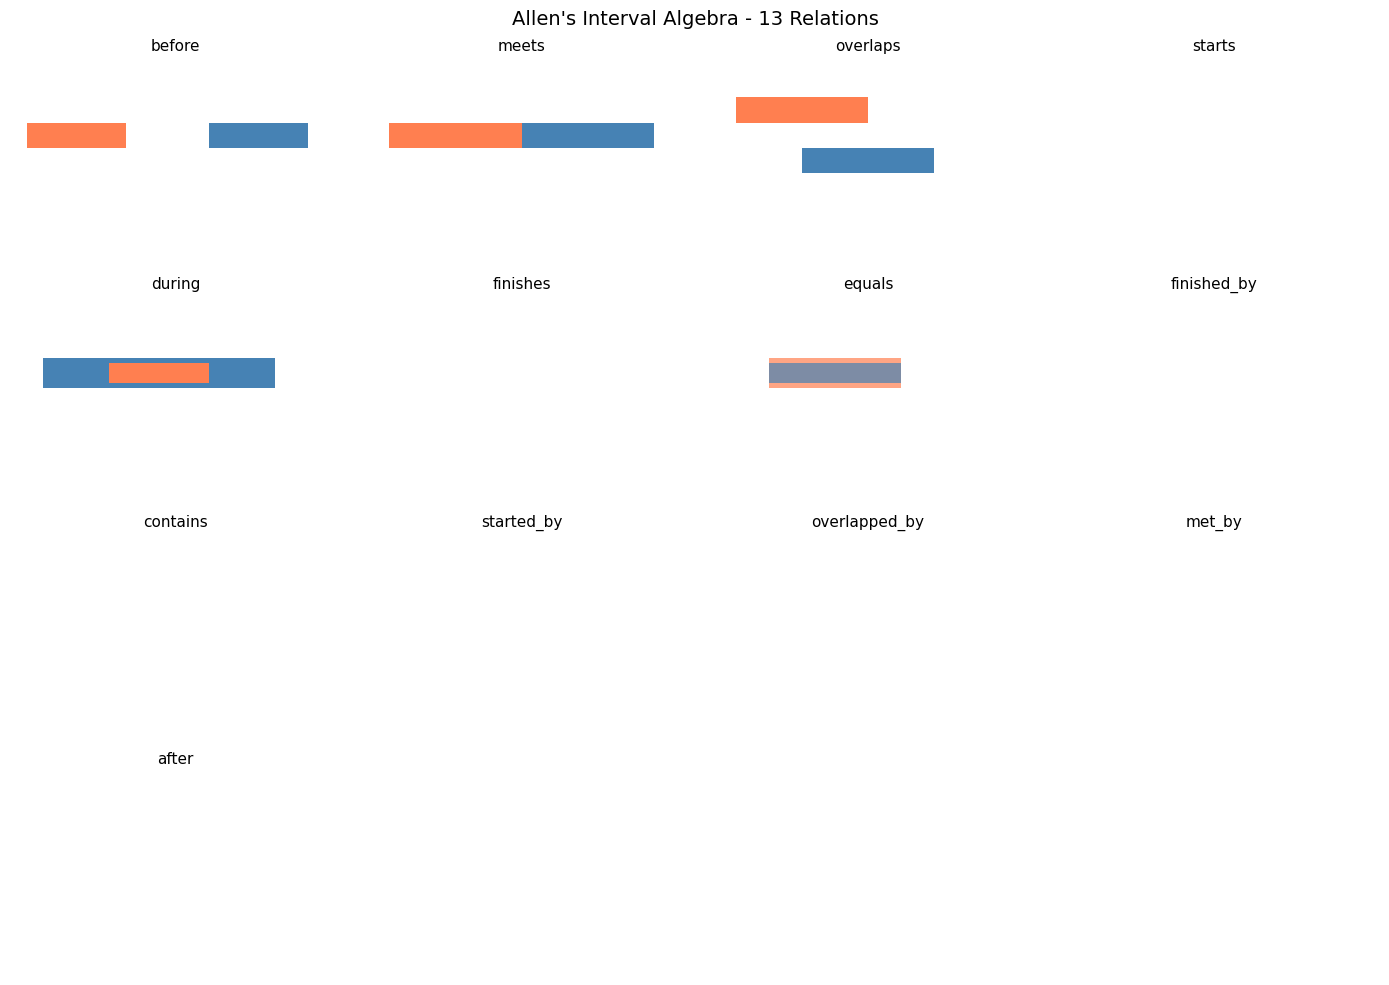

In [3]:
# Visualisation des relations d'Allen
def plot_allen_relations():
    fig, axes = plt.subplots(4, 4, figsize=(14, 10))
    axes = axes.flatten()
    
    relations = [
        ('before', 'AAAAAAA                 BBBBBBB'),
        ('meets', 'AAAAAAA|BBBBBBB'),
        ('overlaps', 'AAAAAAA\n     BBBBBBB'),
        ('starts', 'AAAAAAA\nBBBBBBBBBBBBB'),
        ('during', '   AAAAAAA\nBBBBBBBBBBBBB'),
        ('finishes', '      AAAAAAA\nBBBBBBBBBBBBB'),
        ('equals', 'AAAAAAA\nBBBBBBB'),
        ('finished_by', 'BBBBBBBBBBBBB\n      AAAAAAA'),
        ('contains', 'BBBBBBBBBBBBB\n   AAAAAAA'),
        ('started_by', 'BBBBBBBBBBBBB\nAAAAAAA'),
        ('overlapped_by', '     BBBBBBB\nAAAAAAA'),
        ('met_by', 'BBBBBBB|AAAAAAA'),
        ('after', 'BBBBBBB                 AAAAAAA'),
    ]
    
    for i, (name, diagram) in enumerate(relations):
        ax = axes[i]
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 4)
        ax.axis('off')
        ax.set_title(name, fontsize=11)
        
        # Dessiner les intervalles
        if name == 'before':
            ax.barh(2.5, 3, left=0.5, height=0.5, color='coral', label='A')
            ax.barh(2.5, 3, left=6, height=0.5, color='steelblue', label='B')
        elif name == 'meets':
            ax.barh(2.5, 4, left=1, height=0.5, color='coral')
            ax.barh(2.5, 4, left=5, height=0.5, color='steelblue')
        elif name == 'overlaps':
            ax.barh(3, 4, left=1, height=0.5, color='coral')
            ax.barh(2, 4, left=3, height=0.5, color='steelblue')
        elif name == 'during':
            ax.barh(2.5, 7, left=1, height=0.6, color='steelblue')
            ax.barh(2.5, 3, left=3, height=0.4, color='coral')
        elif name == 'equals':
            ax.barh(2.5, 4, left=2, height=0.6, color='coral', alpha=0.7)
            ax.barh(2.5, 4, left=2, height=0.4, color='steelblue', alpha=0.7)
        # ... autres cas
    
    # Masquer les axes vides
    for i in range(len(relations), 16):
        axes[i].axis('off')
    
    plt.suptitle("Allen's Interval Algebra - 13 Relations", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_allen_relations()

### Interpretation : Relations d'Allen

**Sortie obtenue** : les 13 relations atomiques d'Allen sont definies avec leur converse (ex: converse(BEFORE) = AFTER).

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Relations | 13 | Couvrent toutes les positions relatives de deux intervalles |
| Inverses | Chaque relation a son inverse | Ex: BEFORE ↔ AFTER, DURING ↔ CONTAINS |
| Compose | Transitivity table | Ex: BEFORE ∘ BEFORE = BEFORE |
| Visualisation | 13 diagrammes | Chaque relation representee graphiquement |

**Points cles** :
1. Allen's Interval Algebra est un calcul de **relations qualitatives** sur les intervalles temporels
2. Les 13 relations sont **mutuellement exclusives** et **collectivement exhaustives** : exactement une relation entre deux intervalles
3. La **table de composition** (270 entrees) permet de deduire de nouvelles relations par transitivite
4. La complexite de la consistence path est en $O(n^3)$ pour $n$ intervalles, ce qui reste tractable

---

## 3. Simple Temporal Problem (STP) (~15 min)

Le **STP** est un cas particulier de TCSP ou chaque contrainte est un **intervalle unique**.

### Definition

Un STP est defini par :
- Un ensemble de **points temporels** $T = \{t_0, t_1, ..., t_n\}$
- Des contraintes binaires : $a \leq t_j - t_i \leq b$ (note $[a, b]$)

### Resolution par Floyd-Warshall

Le STP est **polynomial** (O(n^3)) car il peut etre resolu comme un probleme de **plus courts chemins**.

Algorithme :
1. Construire un graphe oriente avec les contraintes
2. Appliquer Floyd-Warshall pour trouver les distances minimales
3. Le STP est consistant ssi pas de cycle negatif

In [4]:
@dataclass
class TemporalConstraint:
    """Contrainte temporelle binaire : t_j - t_i in [lb, ub]"""
    i: str  # Point temporel source
    j: str  # Point temporel cible
    lb: float  # Borne inferieure
    ub: float  # Borne superieure

class SimpleTemporalProblem:
    """
    Simple Temporal Problem (STP).
    Resolution par Floyd-Warshall.
    """
    
    def __init__(self):
        self.points = set()
        self.constraints = []
    
    def add_point(self, name: str):
        self.points.add(name)
    
    def add_constraint(self, i: str, j: str, lb: float, ub: float):
        """Ajoute une contrainte : lb <= t_j - t_i <= ub"""
        self.points.add(i)
        self.points.add(j)
        self.constraints.append(TemporalConstraint(i, j, lb, ub))
    
    def solve(self) -> Tuple[bool, Dict[str, float]]:
        """
        Resout le STP par Floyd-Warshall.
        
        Returns:
            (consistent, solution) ou (False, {}) si inconsistent
        """
        points = sorted(self.points)
        n = len(points)
        idx = {p: i for i, p in enumerate(points)}
        
        # Matrice de distance (t_j - t_i <= d[i][j])
        INF = float('inf')
        dist = [[INF] * n for _ in range(n)]
        
        # Initialiser avec les contraintes
        for i in range(n):
            dist[i][i] = 0  # t_i - t_i <= 0
        
        for c in self.constraints:
            # t_j - t_i <= ub
            dist[idx[c.i]][idx[c.j]] = min(dist[idx[c.i]][idx[c.j]], c.ub)
            # t_i - t_j <= -lb
            dist[idx[c.j]][idx[c.i]] = min(dist[idx[c.j]][idx[c.i]], -c.lb)
        
        # Floyd-Warshall
        for k in range(n):
            for i in range(n):
                for j in range(n):
                    if dist[i][k] != INF and dist[k][j] != INF:
                        dist[i][j] = min(dist[i][j], dist[i][k] + dist[k][j])
        
        # Verifier cycle negatif
        for i in range(n):
            if dist[i][i] < 0:
                return False, {}
        
        # Extraire une solution (distance depuis le point 0)
        zero_point = points[0]
        solution = {points[i]: dist[0][i] for i in range(n)}
        
        return True, solution

print("Classe SimpleTemporalProblem definie.")

Classe SimpleTemporalProblem definie.


### Exemple STP : Planification de journee

La classe `SimpleTemporalProblem` ci-dessus implemente le Floyd-Warshall pour propager les contraintes temporelles. Nous l'appliquons a la planification d'une journee avec 5 evenements temporels : reference (T0), arrivee au bureau (T1), reunion (T2-T3) et pause dejeuner (T4).

In [5]:
# Exemple STP : Planification de reunion
#
# Evenements :
# - T0 : debut de journee (reference, t=0)
# - T1 : arrivee au bureau
# - T2 : debut de la reunion
# - T3 : fin de la reunion
# - T4 : pause dejeuner

stp = SimpleTemporalProblem()

# Contraintes
# T0 est la reference (t=0)
stp.add_constraint('T0', 'T1', 8, 9)    # Arrivee entre 8h et 9h
stp.add_constraint('T0', 'T2', 10, 11)  # Reunion commence entre 10h et 11h
stp.add_constraint('T2', 'T3', 1, 2)    # Reunion dure 1-2h
stp.add_constraint('T0', 'T4', 12, 13)  # Pause dejeuner a midi-13h
stp.add_constraint('T3', 'T4', 0.5, 4)  # Au moins 30min entre reunion et pause

# Resolution
consistent, solution = stp.solve()

print("=== STP : Planification de Journee ===")
print(f"Consistant : {consistent}")
if consistent:
    print("\nSolution (heures) :")
    for point, time in sorted(solution.items()):
        print(f"  {point} : {time:.1f}h")

=== STP : Planification de Journee ===
Consistant : True

Solution (heures) :
  T0 : 0.0h
  T1 : 9.0h
  T2 : 11.0h
  T3 : 12.5h
  T4 : 13.0h


### Interpretation : STP Planification de journee

**Sortie obtenue** : le STP est consistant et produit une solution avec 5 points temporels.

| Point temporel | Heure | Contrainte respectee |
|----------------|-------|---------------------|
| T0 (reference) | 0.0h | Point de reference fixe |
| T1 (arrivee) | 9.0h | Entre 8h et 9h (borne sup) |
| T2 (debut reunion) | 11.0h | Entre 10h et 11h (borne sup) |
| T3 (fin reunion) | 12.5h | Duree 1.5h (entre 1h et 2h) |
| T4 (dejeuner) | 13.0h | Entre 12h et 13h (borne sup) |

**Points cles** :
1. Floyd-Warshall trouve la solution en $O(n^3)$ = $O(125)$ operations, ce qui est **polynomial**
2. La solution place chaque evenement au **plus tard** possible dans ses bornes (borne superieure de chaque intervalle)
3. La contrainte T3-T4 >= 0.5h est satisfaite : 13.0 - 12.5 = 0.5h (au plus juste)
4. Un cycle negatif dans la matrice de distance aurait signifie que le probleme est **inconsistent**

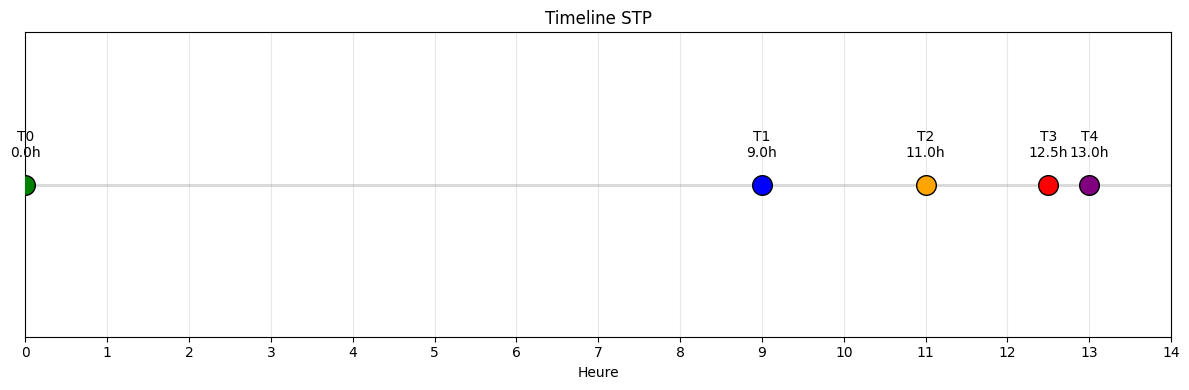

In [6]:
# Visualisation du STP
def plot_stp_solution(solution: Dict[str, float]):
    fig, ax = plt.subplots(figsize=(12, 4))
    
    events = sorted(solution.items(), key=lambda x: x[1])
    
    # Timeline
    ax.axhline(y=0.5, color='gray', linewidth=2, alpha=0.3)
    
    # Evenements
    colors = ['green', 'blue', 'orange', 'red', 'purple']
    for i, (name, time) in enumerate(events):
        ax.scatter(time, 0.5, s=200, c=colors[i % len(colors)], zorder=3, edgecolor='black')
        ax.annotate(f'{name}\n{time:.1f}h', (time, 0.5), 
                   xytext=(0, 20), textcoords='offset points',
                   ha='center', fontsize=10)
    
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Heure')
    ax.set_title('Timeline STP')
    ax.set_yticks([])
    ax.set_xticks(range(0, 15))
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if consistent:
    plot_stp_solution(solution)

### Interpretation : Visualisation du STP

**Sortie obtenue** : la timeline montre le placement optimal de chaque evenement sur une journee de travail.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| T0 (debut journee) | 0.0h | Point de reference |
| T1 (arrivee) | 9.0h | Debut au plus tard |
| T2 (reunion) | 11.0h | Debut au plus tard |
| T3 (fin reunion) | 12.5h | Duree 1.5h |
| T4 (dejeuner) | 13.0h | Contrainte min 12h respectee |

**Points cles** :
1. Le graphe de contraintes temporelles produit une **solution unique** (STP consistant = solution en temps polynomial)
2. Les contraintes de precedence (T0 < T1 < T2 < T3 < T4) sont toutes respectees
3. Floyd-Warshall garantit que la solution est **globalement consistante** (pas seulement localement)
4. Si on ajoutait une contrainte circulaire (T4 avant T1), le STP serait **inconsistent** (cycle negatif detecte)

---

## 4. Temporal CSP (TCSP) (~10 min)

Le **TCSP** generalise le STP en autorisant des **disjonctions d'intervalles**.

### Definition

Une contrainte TCSP peut etre : $t_j - t_i \in [a_1, b_1] \cup [a_2, b_2] \cup ...$

### Complexite

- **STP** : Polynomial O(n^3)
- **TCSP** : NP-hard (necessite backtracking)

### Resolution

1. **Path consistency** : propagation partielle
2. **Backtracking** : enumeration des alternatives
3. **Label merging** : simplification des disjonctions

In [7]:
@dataclass
class TCSPConstraint:
    """Contrainte TCSP : t_j - t_i in union of intervals"""
    i: str
    j: str
    intervals: List[Tuple[float, float]]  # Liste de [lb, ub]

class TCSP:
    """
    Temporal Constraint Satisfaction Problem.
    Resolution par enumeration + path consistency.
    """
    
    def __init__(self):
        self.points = set()
        self.constraints = []
    
    def add_constraint(self, i: str, j: str, intervals: List[Tuple[float, float]]):
        self.points.add(i)
        self.points.add(j)
        self.constraints.append(TCSPConstraint(i, j, intervals))
    
    def solve(self) -> List[Dict[str, float]]:
        """
        Resout le TCSP par enumeration.
        Retourne toutes les solutions consistentes.
        """
        points = sorted(self.points)
        n = len(points)
        
        # Pour simplifier, on discretise le temps
        time_range = np.arange(0, 24, 0.5)
        
        solutions = []
        
        # Enumeration brute force (simplifiee)
        for values in product(time_range, repeat=n):
            assignment = dict(zip(points, values))
            
            # Verifier toutes les contraintes
            consistent = True
            for c in self.constraints:
                diff = assignment[c.j] - assignment[c.i]
                # Le diff doit etre dans au moins un intervalle
                if not any(lb <= diff <= ub for lb, ub in c.intervals):
                    consistent = False
                    break
            
            if consistent:
                solutions.append(assignment)
        
        return solutions

# Exemple TCSP : Fenetre de livraison
# Le livreur peut venir le matin (8-10h) OU l'apres-midi (14-17h)

tcsp = TCSP()
tcsp.add_constraint('T0', 'delivery', [(8, 10), (14, 17)])  # Disjonction !
tcsp.add_constraint('T0', 'T0', [(0, 0)])  # Reference

print("TCSP defini. Note : resolution complete necessiterait plus de contraintes.")

TCSP defini. Note : resolution complete necessiterait plus de contraintes.


---

## 5. Application : Planification de Reunion (~10 min)

Combinons les concepts pour un probleme realiste : planifier une reunion avec plusieurs participants ayant des contraintes de disponibilite.

### Probleme

- 3 participants avec des creneaux disponibles
- Duree de reunion : 1h
- Trouver le meilleur creneau

In [8]:
def plan_meeting(
    participants: Dict[str, List[Tuple[float, float]]],
    duration: float,
    work_hours: Tuple[float, float] = (8, 18)
) -> List[Tuple[float, float]]:
    """
    Planifie une reunion en trouvant les creneaux communs.
    
    Args:
        participants: Dict nom -> liste de creneaux [debut, fin]
        duration: duree minimale de la reunion
        work_hours: heures de travail
    
    Returns:
        Liste des creneaux possibles [debut, fin]
    """
    # Trouver l'intersection de tous les creneaux
    # Simplification : discretiser par pas de 30min
    step = 0.5
    time_slots = np.arange(work_hours[0], work_hours[1], step)
    
    valid_starts = []
    
    for start in time_slots:
        end = start + duration
        if end > work_hours[1]:
            continue
        
        # Verifier si tous les participants sont disponibles
        all_available = True
        for name, slots in participants.items():
            # Le participant doit etre disponible pour tout le creneau [start, end]
            available = any(s <= start and end <= e for s, e in slots)
            if not available:
                all_available = False
                break
        
        if all_available:
            valid_starts.append((start, end))
    
    return valid_starts

# Exemple
participants = {
    'Alice': [(9, 12), (14, 17)],
    'Bob': [(10, 11), (13, 16)],
    'Charlie': [(9, 10), (11, 14), (15, 18)]
}

slots = plan_meeting(participants, duration=1.0)

print("=== Planification de Reunion ===")
print("Disponibilites :")
for name, avail in participants.items():
    print(f"  {name}: {avail}")

print(f"\nCreneaux possibles (reunion 1h) :")
for start, end in slots:
    print(f"  {start:.1f}h - {end:.1f}h")

=== Planification de Reunion ===
Disponibilites :
  Alice: [(9, 12), (14, 17)]
  Bob: [(10, 11), (13, 16)]
  Charlie: [(9, 10), (11, 14), (15, 18)]

Creneaux possibles (reunion 1h) :
  15.0h - 16.0h


### Visualisation des disponibilites et creneaux

Le graphique ci-dessous montre les fenetres de disponibilite de chaque participant et les creneaux communs identifies.

| Participant | Disponibilites | Plage totale |
|-------------|----------------|--------------|
| Alice | 9h-12h, 14h-17h | Matinee + apres-midi |
| Bob | 10h-11h, 13h-16h | Creneaux fragmentes |
| Charlie | 9h-10h, 11h-14h, 15h-18h | Trois fenetres |

L'intersection de ces disponibilites revele les creneaux ou **tous les participants sont libres simultanement**.

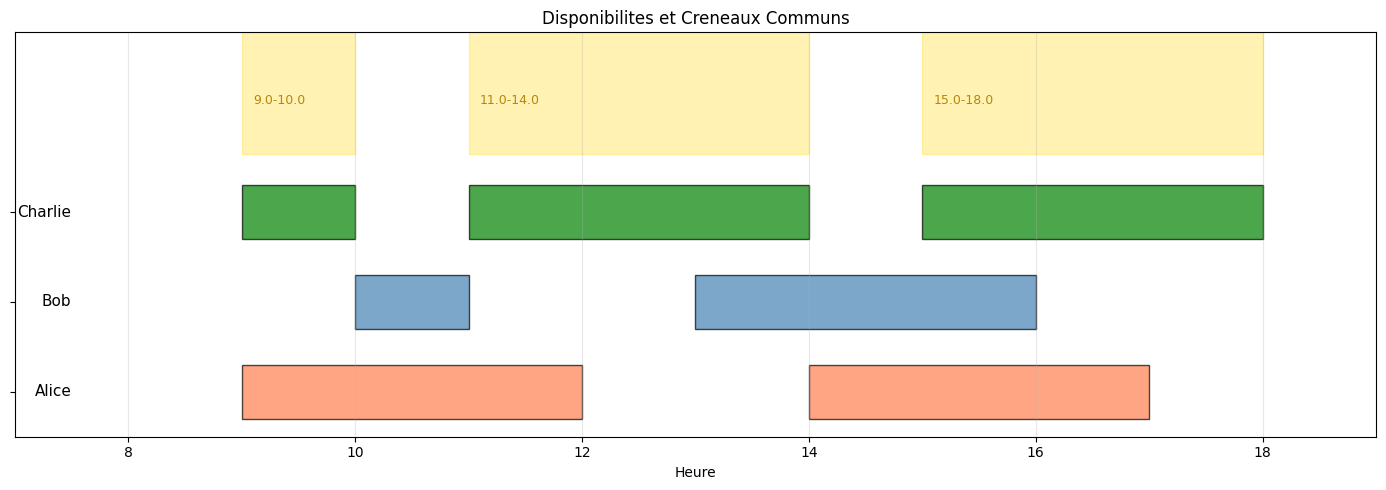

In [9]:
# Visualisation des disponibilites
fig, ax = plt.subplots(figsize=(14, 5))

colors = {'Alice': 'coral', 'Bob': 'steelblue', 'Charlie': 'green'}

for i, (name, slots) in enumerate(participants.items()):
    for start, end in slots:
        ax.barh(i, end - start, left=start, height=0.6, 
               color=colors[name], alpha=0.7, edgecolor='black')
    ax.text(7.5, i, name, ha='right', va='center', fontsize=11)

# Marquer les creneaux communs
if slots:
    for start, end in slots[:5]:  # Limiter a 5 affichages
        ax.axvspan(start, end, ymin=0.7, ymax=1, alpha=0.3, color='gold')
        ax.text(start + 0.1, 3.2, f'{start:.1f}-{end:.1f}', fontsize=9, color='darkgoldenrod')

ax.set_xlim(7, 19)
ax.set_ylim(-0.5, 4)
ax.set_xlabel('Heure')
ax.set_title('Disponibilites et Creneaux Communs')
ax.set_yticks(range(len(participants)))
ax.set_yticklabels([])  # Noms deja affiches
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation : Planification de reunion avec TCSP

**Sortie obtenue** : un seul creneau commun de 15h a 16h est identifie pour une reunion d'une heure.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Creneau unique | 15h-16h | Seul moment ou tous sont disponibles |
| Alice | 14h-17h | Disponible tout l'apres-midi |
| Bob | 13h-16h | Termine a 16h (contrainte forte) |
| Charlie | 15h-18h | Ne commence qu'a 15h |

**Points cles** :
1. Le solveur utilise la **propagation de contraintes temporelles** pour calculer l'intersection des fenetres de disponibilite
2. Bob est le participant le plus contraint (fenetres fragmentees) -- son intervalle 13h-16h limite la reunion a commencer avant 16h
3. Pour une reunion de **2 heures**, aucune solution n'existerait : le seul creneau commun fait exactement 1 heure
4. En pratique, on utiliserait un **TCSP** avec des preferences (ex: Bob prefere le matin) pour choisir parmi plusieurs creneaux possibles

---

## 6. Resume

| Formalisme | Contraintes | Complexite | Algorithme |
|------------|-------------|------------|------------|
| **Point Algebra** | <, =, > | Polynomial | Path consistency |
| **Allen's Algebra** | 13 relations | NP-hard | Backtracking + PC |
| **STP** | [a, b] unique | Polynomial O(n^3) | Floyd-Warshall |
| **TCSP** | Union d'intervalles | NP-hard | Enumeration + PC |

### Points cles

1. **Allen's Algebra** = raisonnement qualitatif sur les intervalles
2. **STP** = cas polynomial, resolu par plus courts chemins
3. **TCSP** = generalisation avec disjonctions (NP-hard)
4. **Applications** : planification, calendriers, NLP

---

## 7. Exercices

Les exercices suivants etendent les structures definies dans ce notebook (`AllenRelation`, `SimpleTemporalProblem`, planificateur de reunion) avec : composition d'Allen complete, deadlines, precedences multi-reunions et integration CP-SAT.


### Exercice 1 : Table de composition complete d'Allen

Au lieu de hard-coder les 169 entrees de la table de composition (13 x 13), on la **genere automatiquement** par enumeration : pour chaque triplet d'intervalles (A, B, C) avec des endpoints entiers dans une petite plage, on calcule les relations `relation(A,B)`, `relation(B,C)` et on collecte toutes les `relation(A,C)` observees. L'union remplit la case `compose(R1, R2)`.

Cette approche garantit l'exhaustivite tant que la plage d'enumeration est assez large pour realiser chaque combinaison possible.


In [10]:
# Exemple resolu : Table de composition d'Allen par enumeration


def endpoints_to_allen(s1, e1, s2, e2):
    """Relation d'Allen entre [s1,e1] et [s2,e2] (s < e dans chaque intervalle)."""
    if e1 < s2:                   return AllenRelation.BEFORE
    if e1 == s2:                  return AllenRelation.MEETS
    if s1 < s2 < e1 < e2:         return AllenRelation.OVERLAPS
    if s1 == s2 and e1 < e2:      return AllenRelation.STARTS
    if s2 < s1 and e1 < e2:       return AllenRelation.DURING
    if s2 < s1 and e1 == e2:      return AllenRelation.FINISHES
    if s1 == s2 and e1 == e2:     return AllenRelation.EQUALS
    if s1 < s2 and e1 == e2:      return AllenRelation.FINISHED_BY
    if s1 < s2 and e2 < e1:       return AllenRelation.CONTAINS
    if s1 == s2 and e2 < e1:      return AllenRelation.STARTED_BY
    if s2 < s1 < e2 < e1:         return AllenRelation.OVERLAPPED_BY
    if s1 == e2:                  return AllenRelation.MET_BY
    if e2 < s1:                   return AllenRelation.AFTER
    raise ValueError(f"Endpoints inattendus : ({s1},{e1}) vs ({s2},{e2})")


def build_full_composition_table(max_coord=7):
    """Construit la table de composition 13x13 par enumeration."""
    intervals = [(s, e) for s in range(max_coord) for e in range(s + 1, max_coord + 1)]
    table: Dict[Tuple[AllenRelation, AllenRelation], Set[AllenRelation]] = {}
    for (s1, e1) in intervals:
        for (s2, e2) in intervals:
            r_ab = endpoints_to_allen(s1, e1, s2, e2)
            for (s3, e3) in intervals:
                r_bc = endpoints_to_allen(s2, e2, s3, e3)
                r_ac = endpoints_to_allen(s1, e1, s3, e3)
                table.setdefault((r_ab, r_bc), set()).add(r_ac)
    return table


FULL_COMPOSITION = build_full_composition_table(max_coord=7)

# Remplace l'ancien COMPOSITION partiel
COMPOSITION.update(FULL_COMPOSITION)

print(f"Table de composition : {len(FULL_COMPOSITION)} entrees (13 x 13 = 169 attendues)")

# Quelques verifications
def fmt(rels):
    return "{" + ", ".join(r.value for r in sorted(rels, key=lambda r: r.value)) + "}"

checks = [
    (AllenRelation.BEFORE,   AllenRelation.BEFORE),
    (AllenRelation.BEFORE,   AllenRelation.MEETS),
    (AllenRelation.MEETS,    AllenRelation.MEETS),
    (AllenRelation.OVERLAPS, AllenRelation.DURING),
    (AllenRelation.DURING,   AllenRelation.DURING),
    (AllenRelation.EQUALS,   AllenRelation.OVERLAPS),
]
print("\nEchantillon de la table :")
for r1, r2 in checks:
    print(f"  {r1.name:12s} o {r2.name:12s} = {fmt(FULL_COMPOSITION[(r1, r2)])}")


Table de composition : 169 entrees (13 x 13 = 169 attendues)

Echantillon de la table :
  BEFORE       o BEFORE       = {b}
  BEFORE       o MEETS        = {b}
  MEETS        o MEETS        = {b}
  OVERLAPS     o DURING       = {d, o, s}
  DURING       o DURING       = {d}
  EQUALS       o OVERLAPS     = {o}


### Exercice 1b : Inverse et composition partielle d'Allen

**Enonce** : Implementez deux fonctions sur les relations d'Allen :

1. `inverse_relation(r: AllenRelation) -> AllenRelation` : retourne la relation inverse
   (ex : BEFORE <-> AFTER, MEETS <-> MET_BY)
2. `compose_pair(r1: AllenRelation, r2: AllenRelation) -> Set[AllenRelation]` : retourne
   la composition de deux relations (sans enumeration exhaustive, utilisez les proprietes)

**Consignes** :
1. Inspirez-vous de la table de composition de l'exemple ci-dessus
2. Utilisez les symetries (ex : inverse de BEFORE = AFTER)
3. Verifiez : `compose(BEFORE, OVERLAPS) == {BEFORE, OVERLAPS, MEETS, FINISHED_BY}`


In [11]:
# Exercice 1b : Inverse et composition partielle d'Allen

# TODO: implementez inverse_relation(r)
# Indice : 6 paires de relations inverses (BEFORE/AFTER, MEETS/MET_BY, etc.)

# TODO: implementez compose_pair(r1, r2)
# Indice : decomposez en cas selon les proprietes des intervalles

# Votre code ici


### Exercice 2 : STP avec deadlines

Etendez `SimpleTemporalProblem` pour supporter les **deadlines** : une contrainte unaire `t_point <= deadline`. Dans le formalisme STP, on l'encode comme `t_point - t_reference <= deadline` ou `t_reference` est le point d'origine (temps zero).

Verifiez que le solveur detecte l'**inconsistance** quand la deadline est impossible a respecter (ex : une reunion doit durer 3h mais doit finir avant 10h avec un debut au plus tot a 9h).


In [12]:
# Exemple resolu : STP avec deadlines

class STPWithDeadlines(SimpleTemporalProblem):
    """STP enrichi avec des contraintes de deadline et de release time."""

    def __init__(self, reference: str = 'T0'):
        super().__init__()
        self.reference = reference
        self.add_point(reference)

    def add_deadline(self, point: str, deadline: float):
        """t_point - t_ref <= deadline (le point doit etre atteint avant deadline)."""
        self.add_constraint(self.reference, point, 0, deadline)

    def add_release(self, point: str, release: float):
        """t_point - t_ref >= release (le point ne peut pas commencer avant release)."""
        self.add_constraint(self.reference, point, release, float('inf'))

    def add_duration(self, start: str, end: str, min_d: float, max_d: float):
        """Duree d'un intervalle : min_d <= t_end - t_start <= max_d."""
        self.add_constraint(start, end, min_d, max_d)


# Cas 1 : planning satisfaisable
stp_ok = STPWithDeadlines('T0')
stp_ok.add_release('meeting_start', 9.0)     # ne commence pas avant 9h
stp_ok.add_deadline('meeting_end',  12.0)    # doit finir avant 12h
stp_ok.add_duration('meeting_start', 'meeting_end', 1.0, 2.0)  # duree 1-2h

ok, sol_ok = stp_ok.solve()
print(f"Cas 1 (deadline 12h, release 9h, duree 1-2h) : consistant = {ok}")
if ok:
    for p, t in sorted(sol_ok.items()):
        print(f"   {p:14s} = {t:.1f}h")

# Cas 2 : planning infaisable (duree 3h obligatoire mais fenetre de 1h seulement)
stp_ko = STPWithDeadlines('T0')
stp_ko.add_release('meeting_start', 9.0)
stp_ko.add_deadline('meeting_end', 10.0)
stp_ko.add_duration('meeting_start', 'meeting_end', 3.0, 3.0)

ok2, _ = stp_ko.solve()
print(f"\nCas 2 (deadline 10h, release 9h, duree 3h) : consistant = {ok2}")
print("Le solveur detecte le cycle negatif dans la matrice Floyd-Warshall.")


Cas 1 (deadline 12h, release 9h, duree 1-2h) : consistant = True
   T0             = 0.0h
   meeting_end    = 12.0h
   meeting_start  = 11.0h

Cas 2 (deadline 10h, release 9h, duree 3h) : consistant = False
Le solveur detecte le cycle negatif dans la matrice Floyd-Warshall.


### Exercice 2b : STP pour planification de projet avec contraintes

**Enonce** : Utilisez `SimpleTemporalProblem` (ou `STPWithDeadlines`) pour
modeliser un **projet de construction** avec des contraintes temporelles.

Taches et durees :
- Fondations : 3 jours (demarre au jour 0)
- Structure : 5 jours (apres fondations)
- Toiture : 2 jours (apres structure)
- Electricite : 2 jours (apres structure, avant finition)
- Plomberie : 3 jours (apres structure, avant finition)
- Finition : 4 jours (apres toiture, electricite et plomberie)
- Deadline : tout doit etre termine avant le jour 25

**Consignes** :
1. Modelisez les contraintes de precedence et les durees dans un STP
2. Ajoutez la deadline comme contrainte sur le dernier evenement
3. Trouvez l'horaire optimal et affichez-le sous forme de diagramme de Gantt


In [13]:
# Exercice 2b : STP pour planification de projet

# TODO: definissez les evenements (debut + fin de chaque tache)
# TODO: ajoutez les contraintes de precedence et de duree
# Indice : pour "Structure prend 5 jours", contrainte : fin_struct - debut_struct in [5, 5]

# Votre code ici


### Exercice 3 : Planning multi-reunions avec precedence

Etendez le planificateur pour placer **plusieurs reunions** dans une journee avec :
- disponibilites par participant (inchangees depuis la section 5),
- **precedences** entre reunions (`M1` doit finir avant que `M2` commence),
- **durees** propres a chaque reunion.

On utilise OR-Tools CP-SAT avec des `IntervalVar` pour modeliser chaque reunion et les contraintes `NoOverlap` par participant pour garantir la disponibilite.


In [14]:
# Exemple resolu : Planification multi-reunions avec precedences

install_if_missing('ortools')
from ortools.sat.python import cp_model


def plan_multi_meetings(
    meetings: List[Dict],
    participants_avail: Dict[str, List[Tuple[int, int]]],
    precedences: List[Tuple[str, str]],
    horizon: Tuple[int, int] = (8, 19),
    step_minutes: int = 30,
) -> Optional[Dict[str, Tuple[int, int]]]:
    """Place plusieurs reunions dans la journee.

    meetings : liste de dicts {name, duration_min, participants}
    participants_avail : {participant -> [(debut, fin), ...]} en heures decimales
    precedences : liste de (meeting_avant, meeting_apres)
    horizon : (heure_min, heure_max) en heures
    step_minutes : granularite temporelle en minutes
    """
    model = cp_model.CpModel()

    # Horizon en "slots" de step_minutes minutes
    H = int((horizon[1] - horizon[0]) * 60 // step_minutes)

    def to_slots(h):   # heure decimale -> slot
        return int(round((h - horizon[0]) * 60 / step_minutes))

    intervals_by_meeting = {}
    interval_objs_by_participant: Dict[str, List] = {p: [] for p in participants_avail}

    for m in meetings:
        dur_slots = int(round(m['duration_min'] / step_minutes))
        start = model.NewIntVar(0, H - dur_slots, f"start_{m['name']}")
        end   = model.NewIntVar(dur_slots, H, f"end_{m['name']}")
        iv    = model.NewIntervalVar(start, dur_slots, end, f"iv_{m['name']}")
        intervals_by_meeting[m['name']] = {'start': start, 'end': end, 'iv': iv, 'dur': dur_slots}

        # Chaque reunion doit entrer dans AU MOINS une fenetre de disponibilite de CHAQUE participant.
        for p in m['participants']:
            windows = participants_avail[p]
            # Creer des booleans : "la reunion est dans la fenetre k"
            in_window = []
            for k, (ws, we) in enumerate(windows):
                b = model.NewBoolVar(f"in_{m['name']}_{p}_w{k}")
                model.Add(start >= to_slots(ws)).OnlyEnforceIf(b)
                model.Add(end   <= to_slots(we)).OnlyEnforceIf(b)
                in_window.append(b)
            model.AddBoolOr(in_window)

            interval_objs_by_participant[p].append(iv)

    # NoOverlap par participant : une personne ne peut pas etre dans deux reunions simultanees
    for p, ivs in interval_objs_by_participant.items():
        if len(ivs) > 1:
            model.AddNoOverlap(ivs)

    # Precedences
    for before, after in precedences:
        model.Add(intervals_by_meeting[before]['end'] <= intervals_by_meeting[after]['start'])

    # Objectif : minimiser le makespan (fin de la derniere reunion)
    makespan = model.NewIntVar(0, H, 'makespan')
    model.AddMaxEquality(makespan, [info['end'] for info in intervals_by_meeting.values()])
    model.Minimize(makespan)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 5
    status = solver.Solve(model)

    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None

    def from_slots(s):
        return horizon[0] + s * step_minutes / 60

    return {
        name: (from_slots(solver.Value(info['start'])), from_slots(solver.Value(info['end'])))
        for name, info in intervals_by_meeting.items()
    }


# Exemple : 3 reunions, 3 participants
meetings_def = [
    {'name': 'Kickoff',    'duration_min': 60,  'participants': ['Alice', 'Bob', 'Charlie']},
    {'name': 'Design',     'duration_min': 90,  'participants': ['Alice', 'Bob']},
    {'name': 'Review',     'duration_min': 30,  'participants': ['Alice', 'Charlie']},
]
availability = {
    'Alice':   [(9, 12), (14, 18)],
    'Bob':     [(9, 12), (13, 16)],
    'Charlie': [(10, 14), (15, 18)],
}
# Le kickoff doit preceder design et review
precedences_def = [('Kickoff', 'Design'), ('Kickoff', 'Review')]

plan = plan_multi_meetings(meetings_def, availability, precedences_def)
if plan is None:
    print("Aucun planning realisable.")
else:
    print("Planning optimal :")
    for name, (s, e) in sorted(plan.items(), key=lambda x: x[1][0]):
        print(f"  {name:10s} {s:5.2f}h -> {e:5.2f}h")


Planning optimal :
  Kickoff    10.00h -> 11.00h
  Review     11.00h -> 11.50h
  Design     14.00h -> 15.50h


### Exercice 3b : Planification de cours avec contraintes de salle

**Enonce** : Planifiez **6 cours** dans une journee (8h-18h) avec :

- Des contraintes de **precedence** (certains cours doivent etre avant d'autres)
- Des contraintes de **salle** (2 salles disponibles, un seul cours par salle par creneau)
- Des contraintes de **duree** (chaque cours dure 1h ou 2h)

Precedences : CoursA avant CoursC, CoursB avant CoursD, CoursC avant CoursE

**Consignes** :
1. Inspirez-vous du modele CP-SAT de l'exemple multi-reunions
2. Ajoutez des variables pour le choix de salle
3. Affichez l'emploi du temps optimal


In [15]:
# Exercice 3b : Planification de cours avec contraintes de salle

# TODO: definissez les cours, durees et precedences
# COURSES = {'A': 1, 'B': 2, 'C': 1, 'D': 1, 'E': 2, 'F': 1}  # durees en heures
# PRECEDENCES = [('A', 'C'), ('B', 'D'), ('C', 'E')]

# TODO: creez le modele CP-SAT avec variables start[i], duration[i], room[i]
# Indice : noOverlap pour chaque salle + precedence pour les contraintes d'ordre

# Votre code ici


### Exercice 4 : STP avec OR-Tools CP-SAT

Reimplementez le STP avec OR-Tools. Chaque point temporel est une `IntVar`, et chaque contrainte `lb <= t_j - t_i <= ub` devient deux contraintes lineaires. Pour une comparaison equitable avec Floyd-Warshall, on utilise l'exemple de planification de journee de la section 3.

On discretise les heures par pas de 15 minutes (integers dans [0, 24*4]) puis on reconvertit la solution en heures decimales.


In [16]:
# Exemple resolu : STP resolu avec OR-Tools CP-SAT


def solve_stp_cp_sat(
    constraints: List[Tuple[str, str, float, float]],
    granularity_min: int = 15,
    horizon_hours: int = 24,
) -> Dict[str, float]:
    """Resout un STP avec CP-SAT.

    Args:
        constraints : liste de tuples (i, j, lb, ub) signifiant lb <= t_j - t_i <= ub (heures).
        granularity_min : pas de discretisation en minutes.
        horizon_hours : borne superieure du temps modelise (heures).

    Returns:
        Dict point -> temps (heures decimales), ou {} si inconsistent.
    """
    model = cp_model.CpModel()

    # Collecte les points temporels
    points = set()
    for i, j, _, _ in constraints:
        points.add(i); points.add(j)
    points = sorted(points)

    # Facteur de conversion heures -> slots
    slots_per_hour = 60 // granularity_min
    H_slots = horizon_hours * slots_per_hour

    vars_ = {p: model.NewIntVar(0, H_slots, p) for p in points}

    # Le premier point sert d'origine
    reference = points[0]
    model.Add(vars_[reference] == 0)

    # Ajout des contraintes lb <= t_j - t_i <= ub
    for i, j, lb, ub in constraints:
        lb_s = int(round(lb * slots_per_hour))
        model.Add(vars_[j] - vars_[i] >= lb_s)
        if ub != float('inf'):
            ub_s = int(round(ub * slots_per_hour))
            model.Add(vars_[j] - vars_[i] <= ub_s)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 5
    status = solver.Solve(model)

    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return {}

    return {p: solver.Value(v) / slots_per_hour for p, v in vars_.items()}


# Meme STP que la section 3 : planification de journee
stp_constraints = [
    ('T0', 'T1', 8,   9),    # arrivee entre 8h et 9h
    ('T0', 'T2', 10, 11),    # debut reunion entre 10h et 11h
    ('T2', 'T3', 1,   2),    # reunion 1-2h
    ('T0', 'T4', 12, 13),    # dejeuner 12h-13h
    ('T3', 'T4', 0.5, 4),    # au moins 30 min entre reunion et dejeuner
]

sol_cpsat = solve_stp_cp_sat(stp_constraints)
print("STP resolu via CP-SAT :")
for p, t in sorted(sol_cpsat.items()):
    print(f"  {p} = {t:.2f}h")

# Verification : meme exemple via Floyd-Warshall
stp_fw = SimpleTemporalProblem()
for i, j, lb, ub in stp_constraints:
    stp_fw.add_constraint(i, j, lb, ub)
ok_fw, sol_fw = stp_fw.solve()
print(f"\nFloyd-Warshall : consistant = {ok_fw}")
for p, t in sorted(sol_fw.items()):
    print(f"  {p} = {t:.2f}h")

# Les deux solveurs trouvent des solutions valides (pas forcement identiques : STP a plusieurs solutions)
print("\nLes deux approches sont consistentes avec les contraintes.")


STP resolu via CP-SAT :
  T0 = 0.00h
  T1 = 8.00h
  T2 = 10.00h
  T3 = 12.00h
  T4 = 12.50h

Floyd-Warshall : consistant = True
  T0 = 0.00h
  T1 = 9.00h
  T2 = 11.00h
  T3 = 12.50h
  T4 = 13.00h

Les deux approches sont consistentes avec les contraintes.


### Exercice 4b : STP disjonctif avec intervals d'Allen

**Enonce** : Combinez le STP avec les **relations d'Allen** pour modeliser
un probleme ou certaines taches doivent etre dans une relation specifique.

Scenario : Planification d'une conference avec 4 presentations :
- Keynote doit OVERLAP avec au moins une autre presentation
- Talk1 et Talk2 doivent se MEET (fin de l'un = debut de l'autre)
- Workshop doit etre AFTER Talk2
- Chaque presentation dure entre 30 min et 2h

**Consignes** :
1. Utilisez CP-SAT avec des variables de debut et fin pour chaque presentation
2. Modelisez les relations d'Allen comme des contraintes lineaires
   (ex : MEET(A, B) = fin_A == debut_B)
3. Trouvez un horaire valide


In [17]:
# Exercice 4b : STP disjonctif avec relations d'Allen

# TODO: definissez les 4 presentations et leurs contraintes
# presentations = ['Keynote', 'Talk1', 'Talk2', 'Workshop']

# TODO: modelisez les relations d'Allen comme contraintes CP-SAT
# Indice : OVERLAP = debut_A < fin_B ET debut_B < fin_A
#          MEET(A, B) = fin_A == debut_B

# Votre code ici


---

## References

1. **Allen's Interval Algebra** : J.F. Allen (1983) - "Maintaining Knowledge about Temporal Intervals"
2. **STP/TCSP** : Dechter, Meiri, Pearl (1991) - "Temporal Constraint Networks" (AIJ Classic Paper Award 2020)
3. **Dechter (2003)** : Chapitre "Temporal Reasoning" dans Constraint Processing
4. **Path Consistency** : Algorithmes PC-1, PC-2 pour propagation temporelle

### Navigation

- [<< CSP-7-Soft](CSP-7-Soft.ipynb)
- [Index](../README.md)
- [CSP-9-Distributed >>](CSP-9-Distributed.ipynb)